In [1]:
import MDAnalysis as mda
from MDAnalysis.analysis import distances, contacts, rms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

import warnings
# suppress some MDAnalysis warnings about writing PDB files
warnings.filterwarnings('ignore')

# the next line is necessary to display plots in Jupyter
%matplotlib inline

In [7]:
peptide = "MECP2"
protein = "WD40"
base_path = f"C:/Users/e216138h/Desktop/Stage/Dossier_Florent/M2/Modelisation/Partenaire/TBL1R/DM/new_MD/m{peptide}_100ns/WT/"

In [8]:
### Analyse DM pour RMSD, RMSF, Rayon de giration et ACP d'une trajectoire ###

2.248234155684431
2.315612
0.2573688679369068


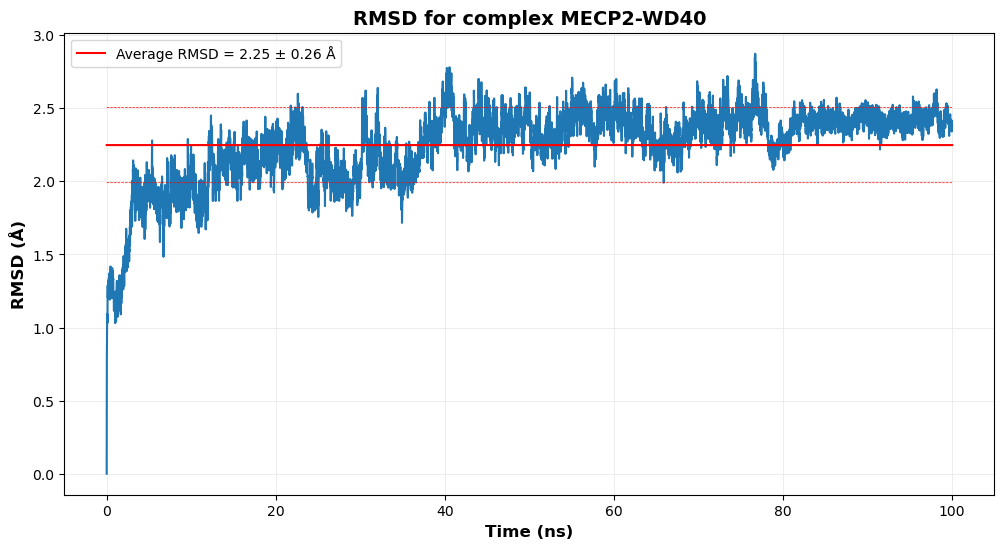

In [9]:
# RMSD vs une référence

x, y = [], []
with open(base_path+"rmsd_vs_start.xvg") as f:
    for line in f:
        if line.startswith(("@", "#")):
            continue
        cols = line.strip().split()
        x.append(float(cols[0])/1000)
        y.append(float(cols[1])*10)

mean_y = np.mean(y)
print(mean_y)
median_y = np.median(y)
print(median_y)
std_y = np.std(y)
print(std_y)

plt.figure(figsize=(12,6))
plt.plot(x, y)
plt.plot(x, np.full_like(y, mean_y, dtype=float), "-", c="red", label=f"Average RMSD = {mean_y:.2f} ± {std_y:.2f} Å")
plt.plot(x, np.full_like(y, (mean_y - std_y), dtype=float), linestyle="--", c="red", linewidth=0.5)
plt.plot(x, np.full_like(y, (mean_y + std_y), dtype=float), linestyle="--", c="red", linewidth=0.5)

plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("RMSD (Å)", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.title(f"RMSD for complex {peptide}-{protein}", fontsize=14, fontweight="bold")
plt.legend()
plt.savefig(f"{base_path}rmsd_plot_start_{peptide}vs{protein}.png", dpi=300)
plt.show()

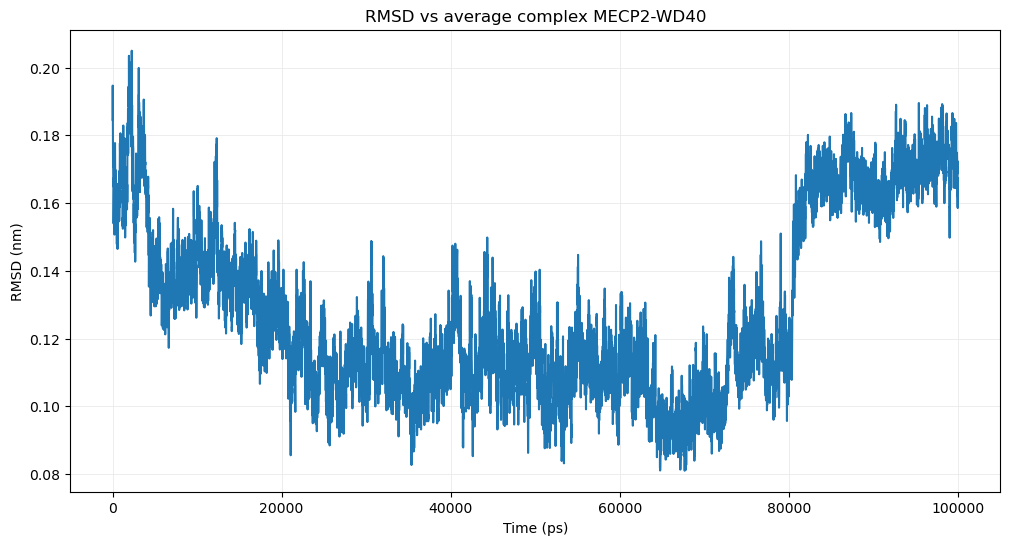

In [10]:
# RMSD vs moyenne

x, y = [], []
with open(base_path+"rmsd_vs_average.xvg") as f:
    for line in f:
        if line.startswith(("@", "#")):
            continue
        cols = line.strip().split()
        x.append(float(cols[0]))
        y.append(float(cols[1]))

plt.figure(figsize=(12,6))
plt.plot(x, y)
plt.xlabel("Time (ps)")
plt.ylabel("RMSD (nm)")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.title(f"RMSD vs average complex {peptide}-{protein}")
plt.show()

4.309613242575742
4.446138
0.8179182922833588


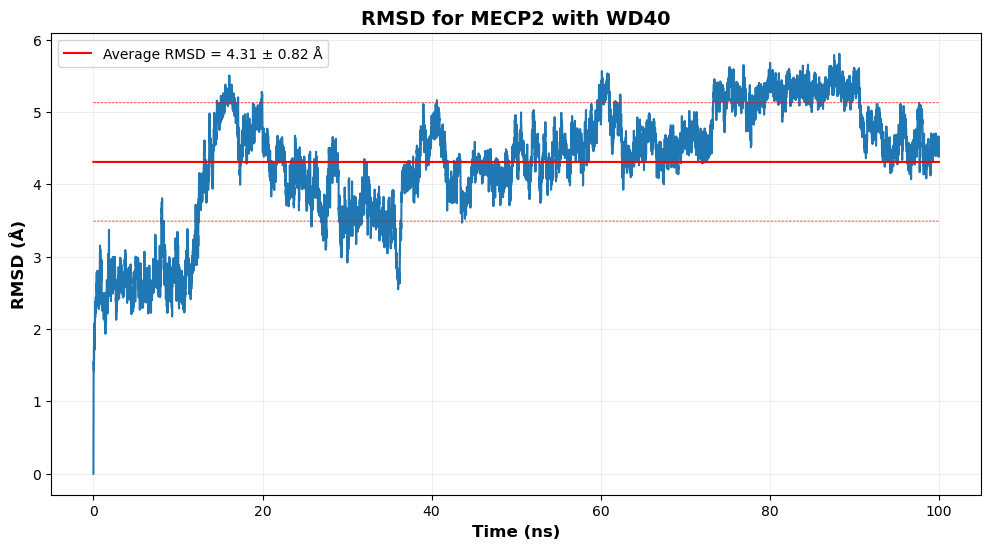

In [11]:
# RMSD MRD vs ref

x, y = [], []
with open(base_path+"rmsd_peptide.xvg") as f:
    for line in f:
        if line.startswith(("@", "#")):
            continue
        cols = line.strip().split()
        x.append(float(cols[0])/1000)
        y.append(float(cols[1])*10)

mean_y = np.mean(y)
print(mean_y)
median_y = np.median(y)
print(median_y)
std_y = np.std(y)
print(std_y)

plt.figure(figsize=(12,6))
plt.plot(x, y)
plt.plot(x, np.full_like(y, mean_y, dtype=float), "-", c="red", label=f"Average RMSD = {mean_y:.2f} ± {std_y:.2f} Å")
plt.plot(x, np.full_like(y, (mean_y - std_y), dtype=float), linestyle="--", c="red", linewidth=0.5)
plt.plot(x, np.full_like(y, (mean_y + std_y), dtype=float), linestyle="--", c="red", linewidth=0.5)

plt.title(f"RMSD for {peptide} with {protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("RMSD (Å)", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.legend()
plt.savefig(f"{base_path}rmsd_plot_start_{peptide}.png", dpi=300)
plt.show()

2.594624496350365
2.6635809999999998
0.2732979803936544


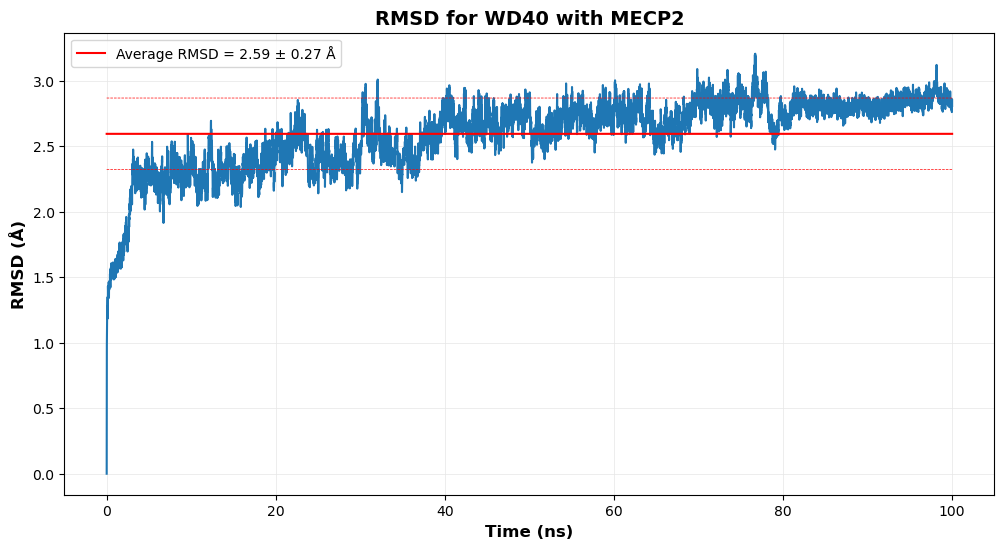

In [12]:
# RMSD WD40 vs ref

x, y = [], []
with open(base_path+"rmsd_protein.xvg") as f:
    for line in f:
        if line.startswith(("@", "#")):
            continue
        cols = line.strip().split()
        x.append(float(cols[0])/1000)
        y.append(float(cols[1])*10)

mean_y = np.mean(y)
print(mean_y)
median_y = np.median(y)
print(median_y)
std_y = np.std(y)
print(std_y)

plt.figure(figsize=(12,6))
plt.plot(x, y)
plt.plot(x, np.full_like(y, mean_y, dtype=float), "-", c="red", label=f"Average RMSD = {mean_y:.2f} ± {std_y:.2f} Å")
plt.plot(x, np.full_like(y, (mean_y - std_y), dtype=float), linestyle="--", c="red", linewidth=0.5)
plt.plot(x, np.full_like(y, (mean_y + std_y), dtype=float), linestyle="--", c="red", linewidth=0.5)

plt.title(f"RMSD for {protein} with {peptide}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("RMSD (Å)", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.legend()
plt.savefig(f"{base_path}rmsd_plot_start_{protein}.png", dpi=300)
plt.show()

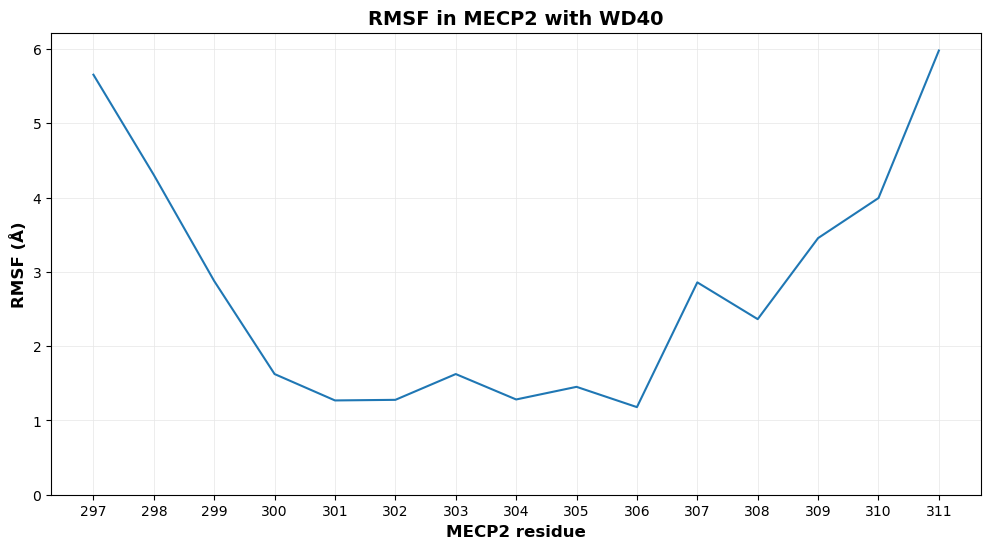

In [13]:
# RMSF par résidus

# MRD
x, y = [], []
with open(base_path+"rmsf_per_residue.xvg") as f:
    i = 0
    for line in f:
        if line.startswith(("@", "#")):
            continue
        i += 1
        if i <= 15:
            cols = line.strip().split()
            x.append(float(cols[0]))
            y.append(float(cols[1])*10)

plt.figure(figsize=(12,6))
plt.plot(x, y)
plt.title(f"RMSF in {peptide} with {protein}", fontsize=14, fontweight="bold")
plt.xlabel(f"{peptide} residue", fontsize=12, fontweight="bold")
plt.ylabel("RMSF (Å)", fontsize=12, fontweight="bold")
plt.ylim(0,)
plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.savefig(f"{base_path}rmsf_plot_{peptide}.png", dpi=300)
plt.show()

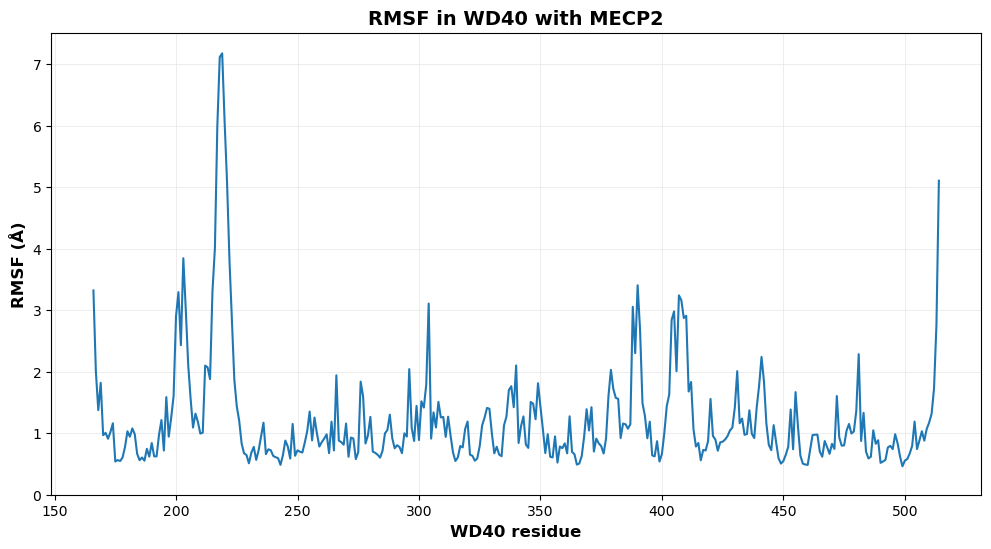

In [14]:
# RMSF par résidus

# WD40
x, y = [], []
with open(base_path+"rmsf_per_residue.xvg") as f:
    i = 0
    for line in f:
        if line.startswith(("@", "#")):
            continue
        i += 1
        if i > 15:
            cols = line.strip().split()
            x.append(float(cols[0]))
            y.append(float(cols[1])*10)

plt.figure(figsize=(12,6))
plt.plot(x, y)
plt.title(f"RMSF in {protein} with {peptide}", fontsize=14, fontweight="bold")
plt.xlabel(f"{protein} residue", fontsize=12, fontweight="bold")
plt.ylabel("RMSF (Å)", fontsize=12, fontweight="bold")
plt.ylim(0,)
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.savefig(f"{base_path}rmsf_plot_{protein}.png", dpi=300)
plt.show()

19.899776362363767
19.8987
0.09250220541914415


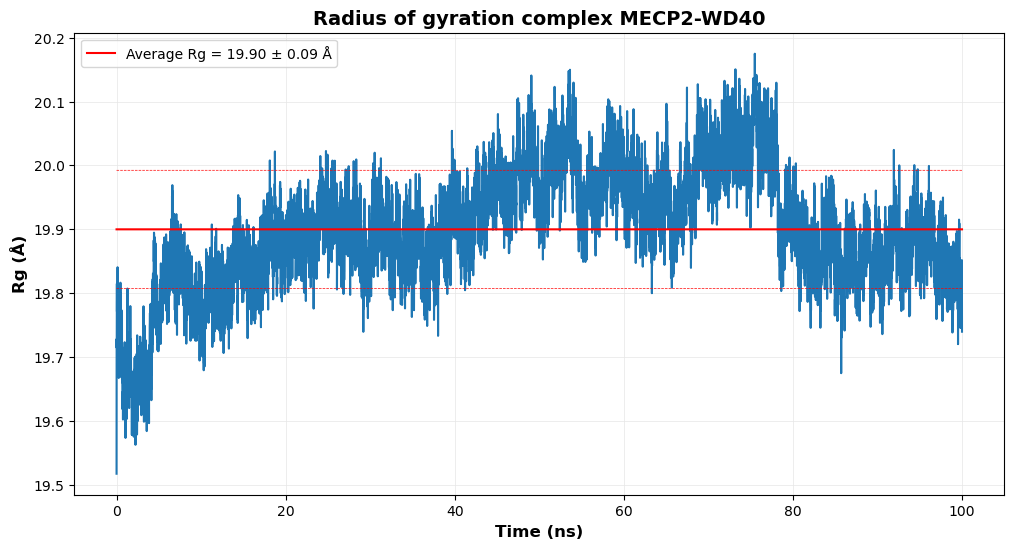

In [15]:
# Rayon de giration

x, y = [], []
with open(base_path+"gyrate.xvg") as f:
    for line in f:
        if line.startswith(("@", "#")):
            continue
        cols = line.strip().split()
        x.append(float(cols[0])/1000)
        y.append(float(cols[1])*10)

mean_y = np.mean(y)
print(mean_y)
median_y = np.median(y)
print(median_y)
std_y = np.std(y)
print(std_y)

plt.figure(figsize=(12,6))
plt.plot(x, y)
plt.plot(x, np.full_like(y, mean_y, dtype=float), "-", c="red", label=f"Average Rg = {mean_y:.2f} ± {std_y:.2f} Å")
plt.plot(x, np.full_like(y, (mean_y - std_y), dtype=float), linestyle="--", c="red", linewidth=0.5)
plt.plot(x, np.full_like(y, (mean_y + std_y), dtype=float), linestyle="--", c="red", linewidth=0.5)

plt.title(f"Radius of gyration complex {peptide}-{protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Rg (Å)", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.legend()
plt.savefig(f"{base_path}gyrate_plot_{peptide}vs{protein}.png", dpi=300)
plt.show()

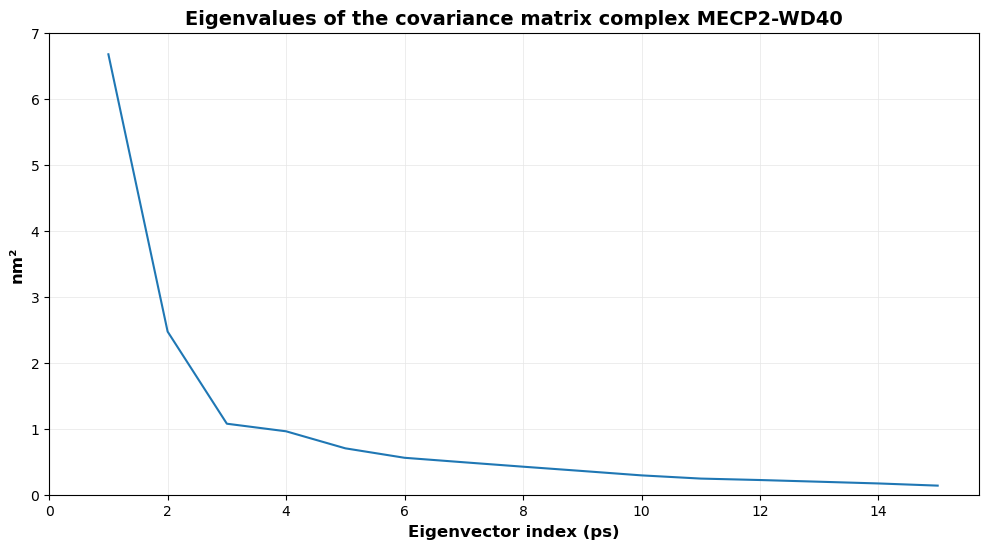

In [16]:
# ACP de la trajectoire

x, y = [], []
with open(base_path+"eigenvalues.xvg") as f:
    i = 0
    for line in f:
        if line.startswith(("@", "#")):
            continue
        i += 1
        if i <= 15:
            cols = line.strip().split()
            x.append(float(cols[0]))
            y.append(float(cols[1]))

plt.figure(figsize=(12,6))
plt.plot(x, y)
plt.title(f"Eigenvalues of the covariance matrix complex {peptide}-{protein}", fontsize=14, fontweight="bold")
plt.xlabel("Eigenvector index (ps)", fontsize=12, fontweight="bold")
plt.ylabel("nm²", fontsize=12, fontweight="bold")
plt.xlim(0,)
plt.ylim(0,)
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.savefig(f"{base_path}eigenvalues_plot_{peptide}.png", dpi=300)
plt.show()

In [17]:
### Etude des contacts d'un complexe protéique lors d'une simulation de DM ###

In [20]:
base_path_md = f"E:/Trajectoire_MD/m{peptide}_100ns/WT/"

GRO = base_path+"md_0_1.gro"
#PDB = base_path+"md_0_1.pdb"
XTC = base_path_md+"md_0_1_noPBC.xtc"

In [21]:
u_gro = mda.Universe(GRO, XTC)
#u_pdb = mda.Universe(PDB, XTC)

In [22]:
# Fonction qui trouve le nombre d'atomes dans le peptide associé au WD40

def find_atoms_numbers(gro_file):
    
    with open(gro_file, "r") as f:
        lines = f.readlines()
    
    atom_lines = lines[2:-1]
    atoms = 0
    
    for line in atom_lines:
        atoms += 1
        if line.startswith("  166ARG      N"):
            return(int(atoms-1))

In [23]:
# ATTENTION: le compte des atomes commencent à 0 pour les fichiers .gro et à 1 pour les fichiers .pdb!
# Et changer le numéros des atomes en fonction du complexe (mNFIL3, mMECP2, mMKX...) => 1er ligne du fichier "output_analyse.out"

peptide_count = find_atoms_numbers(GRO)
print(peptide_count)

protein_begin = peptide_count
protein_end = protein_begin + 5251  # NOTE: ne fonctionne que pour le domaine WD40 de TBL1R!

MRD = u_gro.atoms[0:peptide_count]
print(MRD)
WD40 = u_gro.atoms[protein_begin:protein_end]
print(WD40)

274
<AtomGroup [<Atom 1: N of type N of resname HIS, resid 297 and segid SYSTEM>, <Atom 2: H1 of type H of resname HIS, resid 297 and segid SYSTEM>, <Atom 3: H2 of type H of resname HIS, resid 297 and segid SYSTEM>, ..., <Atom 272: C of type C of resname THR, resid 311 and segid SYSTEM>, <Atom 273: O1 of type O of resname THR, resid 311 and segid SYSTEM>, <Atom 274: O2 of type O of resname THR, resid 311 and segid SYSTEM>]>
<AtomGroup [<Atom 275: N of type N of resname ARG, resid 166 and segid SYSTEM>, <Atom 276: H1 of type H of resname ARG, resid 166 and segid SYSTEM>, <Atom 277: H2 of type H of resname ARG, resid 166 and segid SYSTEM>, ..., <Atom 5523: HZ3 of type H of resname LYS, resid 514 and segid SYSTEM>, <Atom 5524: C of type C of resname LYS, resid 514 and segid SYSTEM>, <Atom 5525: O1 of type O of resname LYS, resid 514 and segid SYSTEM>]>


In [24]:
# Définition des pseudo ponts-salins comme contacts

sel_basic = "(resname ARG LYS HIS) and (name NH* NZ ND1 NE NE2 HH1* HH2* HE HE2 HZ*)"
sel_acidic = "name OE* OD* O"

basic = MRD.select_atoms(sel_basic)
print(basic, len(basic))
acidic = WD40.select_atoms(sel_acidic)
print(acidic, len(acidic))

<AtomGroup [<Atom 11: ND1 of type N of resname HIS, resid 297 and segid SYSTEM>, <Atom 16: NE2 of type N of resname HIS, resid 297 and segid SYSTEM>, <Atom 17: HE2 of type H of resname HIS, resid 297 and segid SYSTEM>, ..., <Atom 240: NH2 of type N of resname ARG, resid 309 and segid SYSTEM>, <Atom 241: HH21 of type H of resname ARG, resid 309 and segid SYSTEM>, <Atom 242: HH22 of type H of resname ARG, resid 309 and segid SYSTEM>]> 34
<AtomGroup [<Atom 300: O of type O of resname ARG, resid 166 and segid SYSTEM>, <Atom 307: O of type O of resname GLY, resid 167 and segid SYSTEM>, <Atom 325: O of type O of resname HIS, resid 168 and segid SYSTEM>, ..., <Atom 5460: O of type O of resname ASP, resid 511 and segid SYSTEM>, <Atom 5479: O of type O of resname LEU, resid 512 and segid SYSTEM>, <Atom 5503: O of type O of resname ARG, resid 513 and segid SYSTEM>]> 453


In [25]:
### Analyse du nombre de contacts ###

In [26]:
# Fonction qui calcule le nombre de contacts entre 2 groupes et dans le rayon définis pour chaque frame de la trajectoire

def contacts_within_cutoff(u, group_a, group_b, radius=4.5):
    timeseries = []
    for ts in u.trajectory:
        # calculate distances between group_a and group_b
        dist = contacts.distance_array(group_a.positions, group_b.positions)
        # determine which distances <= radius
        n_contacts = contacts.contact_matrix(dist, radius).sum()
        timeseries.append([ts.frame, ts.frame/100, n_contacts])
    return np.array(timeseries)

In [27]:
ca = contacts_within_cutoff(u_gro, acidic, basic, radius=4.5)
ca.shape

(10001, 3)

In [28]:
ca_df = pd.DataFrame(ca, columns=["Frame", "Time (ns)", "# Contacts"])
print(ca_df.head(),"\n", ca_df.tail())

   Frame  Time (ns)  # Contacts
0    0.0       0.00        57.0
1    1.0       0.01        55.0
2    2.0       0.02        49.0
3    3.0       0.03        44.0
4    4.0       0.04        43.0 
          Frame  Time (ns)  # Contacts
9996    9996.0      99.96        58.0
9997    9997.0      99.97        60.0
9998    9998.0      99.98        59.0
9999    9999.0      99.99        57.0
10000  10000.0     100.00        54.0


In [29]:
compte_all = ca_df["# Contacts"].value_counts().sort_index()
#print(compte_all)

moyenne_all = ca_df["# Contacts"].mean()
print(moyenne_all)

median_all = ca_df["# Contacts"].median()
print(median_all)

std_all = ca_df["# Contacts"].std()
print(std_all)

55.488251174882514
56.0
8.090567776819181


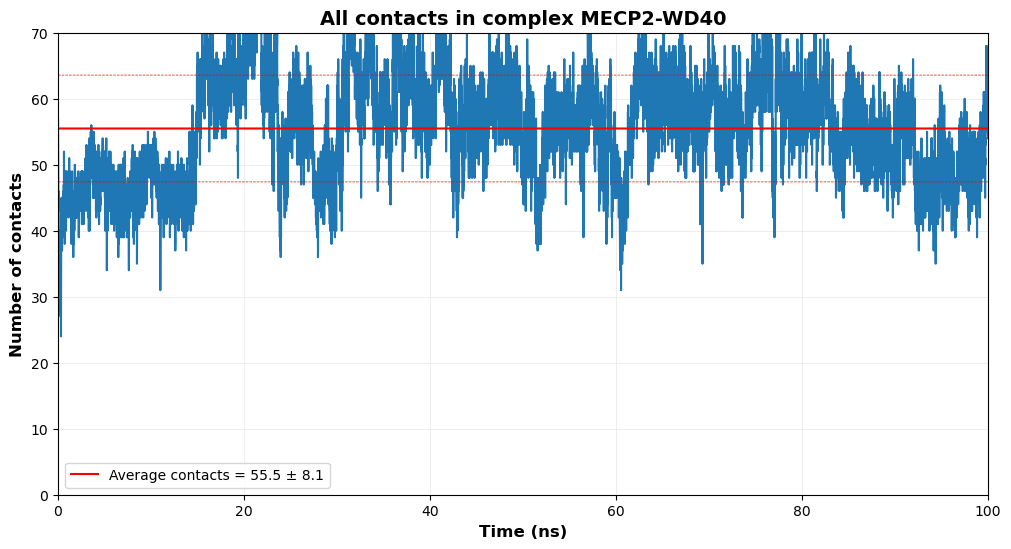

In [30]:
# Graph

plt.figure(figsize=(12,6))
plt.plot(ca_df["Time (ns)"], ca_df["# Contacts"])
plt.plot(ca_df["Time (ns)"], np.full_like(ca_df["Time (ns)"], moyenne_all, dtype=float), linestyle="-", c="red", label=f"Average contacts = {moyenne_all:.1f} ± {std_all:.1f}")
plt.plot(ca_df["Time (ns)"], np.full_like(ca_df["Time (ns)"], (moyenne_all - std_all), dtype=float), linestyle="--", c="red", linewidth=0.5)
plt.plot(ca_df["Time (ns)"], np.full_like(ca_df["Time (ns)"], (moyenne_all + std_all), dtype=float), linestyle="--", c="red", linewidth=0.5)

plt.title(f"All contacts in complex {peptide}-{protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Number of contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0, 100)
plt.ylim(0, 70)
plt.legend()
plt.savefig(f"{base_path}all_contacts_plot_{peptide}vs{protein}.png", dpi=300)
plt.show()

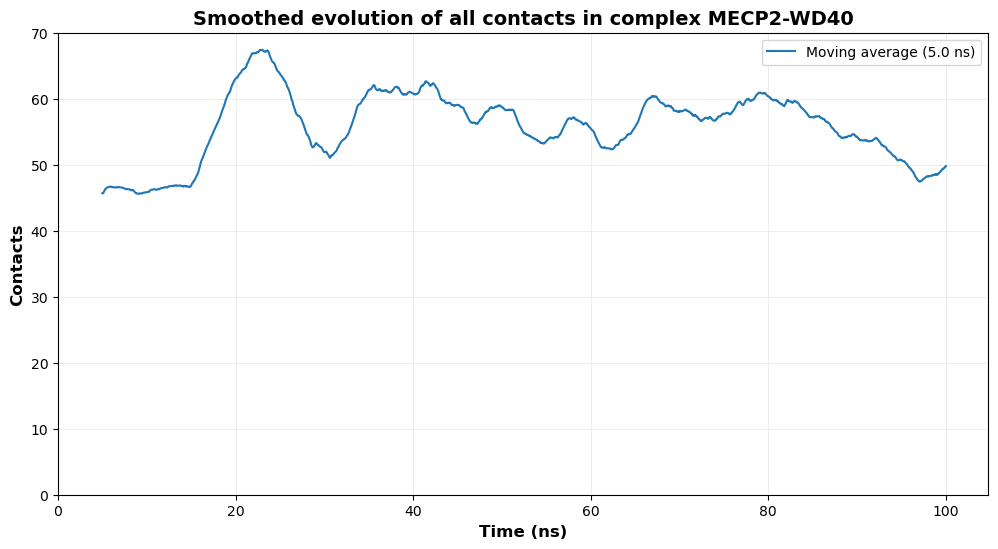

In [31]:
# Graph en "moyenne glissante" pour réduire le bruit de fond

# Averaged 
windows = 500
ca_df["Contacts_smooth"] = ca_df["# Contacts"].rolling(window=windows).mean()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(ca_df["Time (ns)"], ca_df["Contacts_smooth"], label=f"Moving average ({windows/100} ns)")
plt.title(f"Smoothed evolution of all contacts in complex {peptide}-{protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0,)
plt.ylim(0, 70)
plt.legend()
plt.savefig(f"{base_path}all_contacts_plot_{peptide}vs{protein}_smoothed.png", dpi=300)
plt.show()

In [32]:
##### Contacts à partir de résidus spécifiques du MRD et de MECP2 #####

In [33]:
# Sélection des résidus:

sel_H297 = "(resid 297 and name ND1 NE2 HE2)"
sel_R306 = "(resid 306 and name NE NH* HE HH1* HH2*)"
sel_R309 = "(resid 309 and name NE NH* HE HH1* HH2*)"
sel_K304 = "(resid 304 and name NZ HZ*)"
sel_K305 = "(resid 305 and name NZ HZ*)"
sel_K307 = "(resid 307 and name NZ HZ*)"

#sel_all_acidic = "(name OE* OD* O* O)"

H297 = MRD.select_atoms(sel_H297)
R306 = MRD.select_atoms(sel_R306)
R309 = MRD.select_atoms(sel_R309)
K304 = MRD.select_atoms(sel_K304)
K305 = MRD.select_atoms(sel_K305)
K307 = MRD.select_atoms(sel_K307)

all_basic = H297 + R306 + R309 + K304 + K305 + K307
#all_acidic = WD40.select_atoms(sel_all_acidic)

print(H297, R306, R309, K304, K305, K307)
print(len(H297), len(R306), len(R309), len(K304), len(K305), len(K307))
print(all_basic, len(all_basic))
#print(all_acidic, len(all_acidic))

<AtomGroup [<Atom 11: ND1 of type N of resname HIS, resid 297 and segid SYSTEM>, <Atom 16: NE2 of type N of resname HIS, resid 297 and segid SYSTEM>, <Atom 17: HE2 of type H of resname HIS, resid 297 and segid SYSTEM>]> <AtomGroup [<Atom 174: NE of type N of resname ARG, resid 306 and segid SYSTEM>, <Atom 175: HE of type H of resname ARG, resid 306 and segid SYSTEM>, <Atom 177: NH1 of type N of resname ARG, resid 306 and segid SYSTEM>, <Atom 178: HH11 of type H of resname ARG, resid 306 and segid SYSTEM>, <Atom 179: HH12 of type H of resname ARG, resid 306 and segid SYSTEM>, <Atom 180: NH2 of type N of resname ARG, resid 306 and segid SYSTEM>, <Atom 181: HH21 of type H of resname ARG, resid 306 and segid SYSTEM>, <Atom 182: HH22 of type H of resname ARG, resid 306 and segid SYSTEM>]> <AtomGroup [<Atom 234: NE of type N of resname ARG, resid 309 and segid SYSTEM>, <Atom 235: HE of type H of resname ARG, resid 309 and segid SYSTEM>, <Atom 237: NH1 of type N of resname ARG, resid 309 and 

In [34]:
# Pour H297

In [35]:
ca_H297_co = contacts_within_cutoff(u_gro, H297, acidic, radius=4.5)

In [36]:
ca_H297_co_df = pd.DataFrame(ca_H297_co, columns=["Frame", "Time (ns)", "# Contacts"])
print(ca_H297_co_df.head(),"\n", ca_H297_co_df.tail())

   Frame  Time (ns)  # Contacts
0    0.0       0.00         0.0
1    1.0       0.01         0.0
2    2.0       0.02         0.0
3    3.0       0.03         0.0
4    4.0       0.04         0.0 
          Frame  Time (ns)  # Contacts
9996    9996.0      99.96         0.0
9997    9997.0      99.97         0.0
9998    9998.0      99.98         0.0
9999    9999.0      99.99         0.0
10000  10000.0     100.00         0.0


In [37]:
compte_H297 = ca_H297_co_df["# Contacts"].value_counts().sort_index()
#print(compte_H297)

moyenne_H297 = ca_H297_co_df["# Contacts"].mean()
print(moyenne_H297)

median_H297 = ca_H297_co_df["# Contacts"].median()
print(median_H297)

std_H297 = ca_H297_co_df["# Contacts"].std()
print(std_H297)

0.27487251274872515
0.0
0.8266423327203704


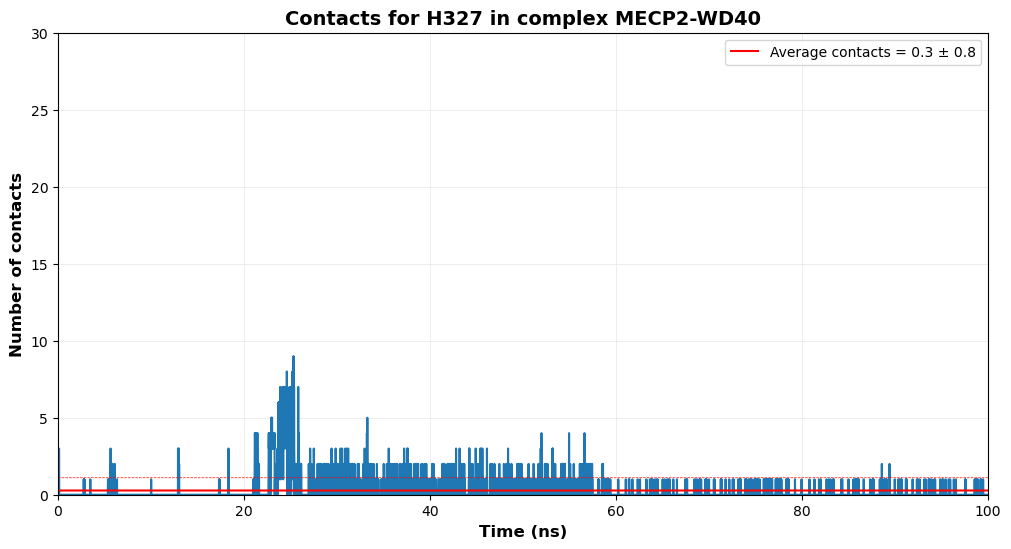

In [38]:
# Graph

plt.figure(figsize=(12,6))
plt.plot(ca_H297_co_df["Time (ns)"], ca_H297_co_df["# Contacts"])
plt.plot(ca_H297_co_df["Time (ns)"], np.full_like(ca_H297_co_df["Time (ns)"], moyenne_H297, dtype=float), linestyle="-", label=f"Average contacts = {moyenne_H297:.1f} ± {std_H297:.1f}", c="red")
plt.plot(ca_H297_co_df["Time (ns)"], np.full_like(ca_H297_co_df["Time (ns)"], (moyenne_H297 - std_H297), dtype=float), linestyle="--", c="red", linewidth=0.5)
plt.plot(ca_H297_co_df["Time (ns)"], np.full_like(ca_H297_co_df["Time (ns)"], (moyenne_H297 + std_H297), dtype=float), linestyle="--", c="red", linewidth=0.5)

plt.title(f"Contacts for H327 in complex {peptide}-{protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Number of contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0, 100)
plt.ylim(0, 30)
plt.legend()
plt.savefig(f"{base_path}H327_contacts_number_plot_{peptide}vs{protein}.png", dpi=300)
plt.show()

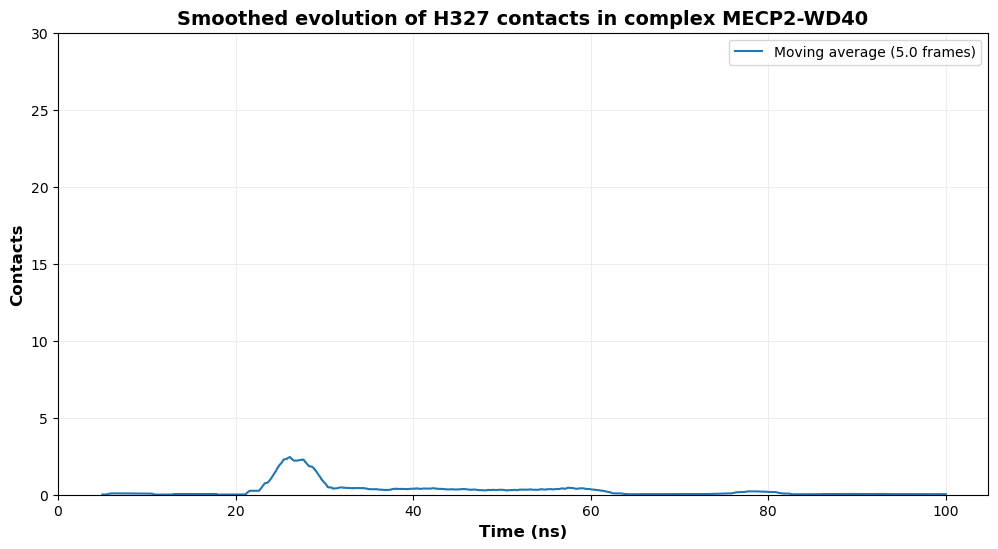

In [39]:
# Graph en "moyenne glissante" pour réduire le bruit de fond

ca_H297_co_df["Contacts_smooth"] = ca_H297_co_df["# Contacts"].rolling(window=windows).mean()

plt.figure(figsize=(12,6))
plt.plot(ca_H297_co_df["Time (ns)"], ca_H297_co_df["Contacts_smooth"], label=f"Moving average ({windows/100} frames)")
plt.title(f"Smoothed evolution of H327 contacts in complex {peptide}-{protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0,)
plt.ylim(0, 30)
plt.legend()
plt.savefig(f"{base_path}H327_contacts_smoothed_plot_{peptide}vs{protein}.png", dpi=300)
plt.show()

In [40]:
# Pour R306

In [41]:
ca_R306_co = contacts_within_cutoff(u_gro, R306, acidic, radius=4.5)

In [42]:
ca_R306_co_df = pd.DataFrame(ca_R306_co, columns=["Frame", "Time (ns)", "# Contacts"])
print(ca_R306_co_df.head(),"\n", ca_R306_co_df.tail())

   Frame  Time (ns)  # Contacts
0    0.0       0.00        18.0
1    1.0       0.01        15.0
2    2.0       0.02        13.0
3    3.0       0.03        14.0
4    4.0       0.04        13.0 
          Frame  Time (ns)  # Contacts
9996    9996.0      99.96        16.0
9997    9997.0      99.97        18.0
9998    9998.0      99.98        21.0
9999    9999.0      99.99        19.0
10000  10000.0     100.00        21.0


In [43]:
compte_R306 = ca_R306_co_df["# Contacts"].value_counts().sort_index()
#print(compte_R306)

moyenne_R306 = ca_R306_co_df["# Contacts"].mean()
print(moyenne_R306)

median_R306 = ca_R306_co_df["# Contacts"].median()
print(median_R306)

std_R306 = ca_R306_co_df["# Contacts"].std()
print(std_R306)

14.884111588841115
15.0
3.6905377024421093


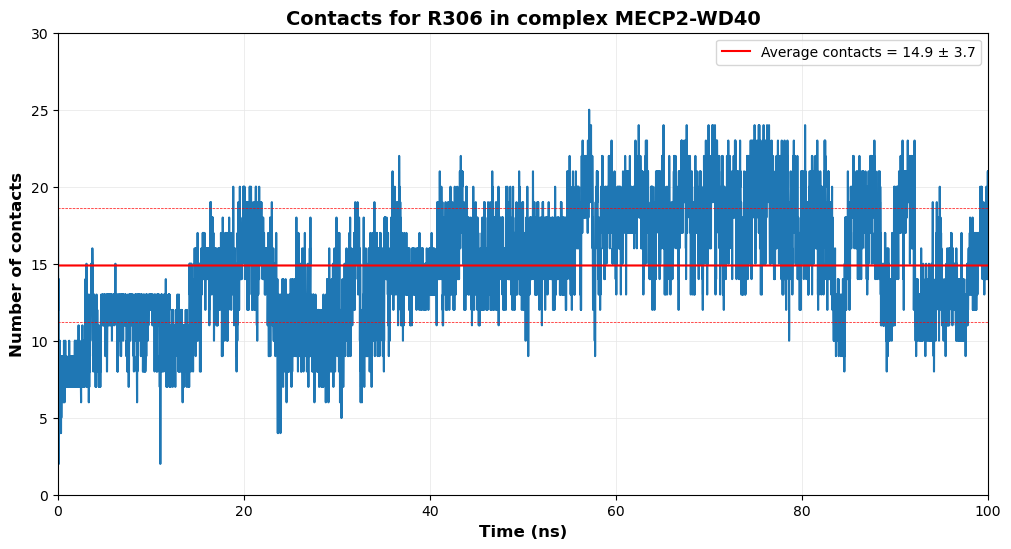

In [44]:
# Graph

plt.figure(figsize=(12,6))
plt.plot(ca_R306_co_df["Time (ns)"], ca_R306_co_df["# Contacts"])
plt.plot(ca_R306_co_df["Time (ns)"], np.full_like(ca_R306_co_df["Time (ns)"], moyenne_R306, dtype=float), linestyle="-", label=f"Average contacts = {moyenne_R306:.1f} ± {std_R306:.1f}", c="red")
plt.plot(ca_R306_co_df["Time (ns)"], np.full_like(ca_R306_co_df["Time (ns)"], (moyenne_R306 - std_R306), dtype=float), linestyle="--", c="red", linewidth=0.5)
plt.plot(ca_R306_co_df["Time (ns)"], np.full_like(ca_R306_co_df["Time (ns)"], (moyenne_R306 + std_R306), dtype=float), linestyle="--", c="red", linewidth=0.5)

plt.title(f"Contacts for R306 in complex {peptide}-{protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Number of contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0, 100)
plt.ylim(0, 30)
plt.legend()
plt.savefig(f"{base_path}R306_contacts_number_plot_{peptide}vs{protein}.png", dpi=300)
plt.show()

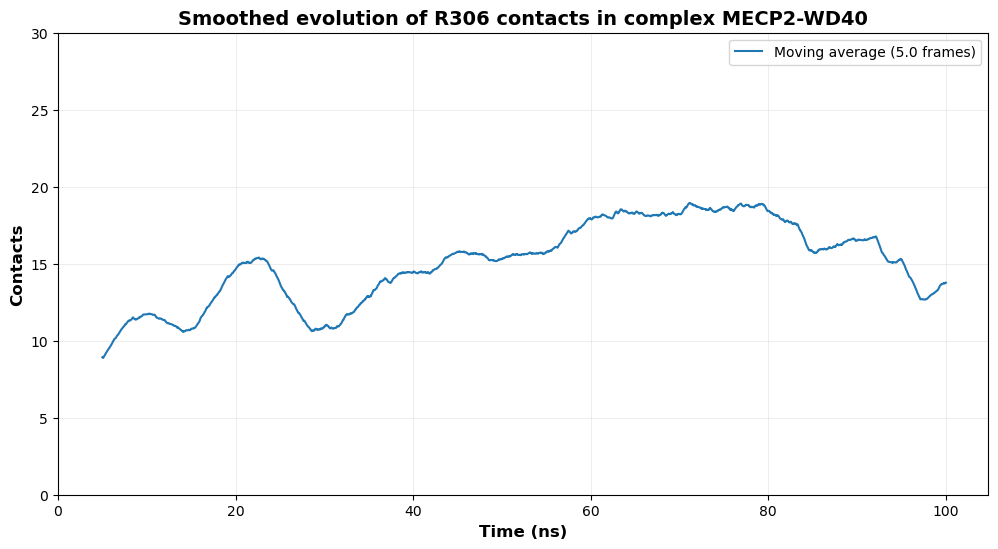

In [45]:
# Graph en "moyenne glissante" pour réduire le bruit de fond

ca_R306_co_df["Contacts_smooth"] = ca_R306_co_df["# Contacts"].rolling(window=windows).mean()

plt.figure(figsize=(12,6))
plt.plot(ca_R306_co_df["Time (ns)"], ca_R306_co_df["Contacts_smooth"], label=f"Moving average ({windows/100} frames)")
plt.title(f"Smoothed evolution of R306 contacts in complex {peptide}-{protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0,)
plt.ylim(0, 30)
plt.legend()
plt.savefig(f"{base_path}R306_contacts_smoothed_plot_{peptide}vs{protein}.png", dpi=300)
plt.show()

In [46]:
# Pour R309

In [47]:
ca_R309_co = contacts_within_cutoff(u_gro, R309, acidic, radius=4.5)

In [48]:
ca_R309_co_df = pd.DataFrame(ca_R309_co, columns=["Frame", "Time (ns)", "# Contacts"])
print(ca_R309_co_df.head(),"\n", ca_R309_co_df.tail())

   Frame  Time (ns)  # Contacts
0    0.0       0.00         0.0
1    1.0       0.01         0.0
2    2.0       0.02         0.0
3    3.0       0.03         0.0
4    4.0       0.04         0.0 
          Frame  Time (ns)  # Contacts
9996    9996.0      99.96        11.0
9997    9997.0      99.97        12.0
9998    9998.0      99.98        11.0
9999    9999.0      99.99        11.0
10000  10000.0     100.00        12.0


In [49]:
compte_R309 = ca_R309_co_df["# Contacts"].value_counts().sort_index()
#print(compte_R309)

moyenne_R309 = ca_R309_co_df["# Contacts"].mean()
print(moyenne_R309)

median_R309 = ca_R309_co_df["# Contacts"].median()
print(median_R309)

std_R309 = ca_R309_co_df["# Contacts"].std()
print(std_R309)

7.6106389361063895
11.0
5.740730162768481


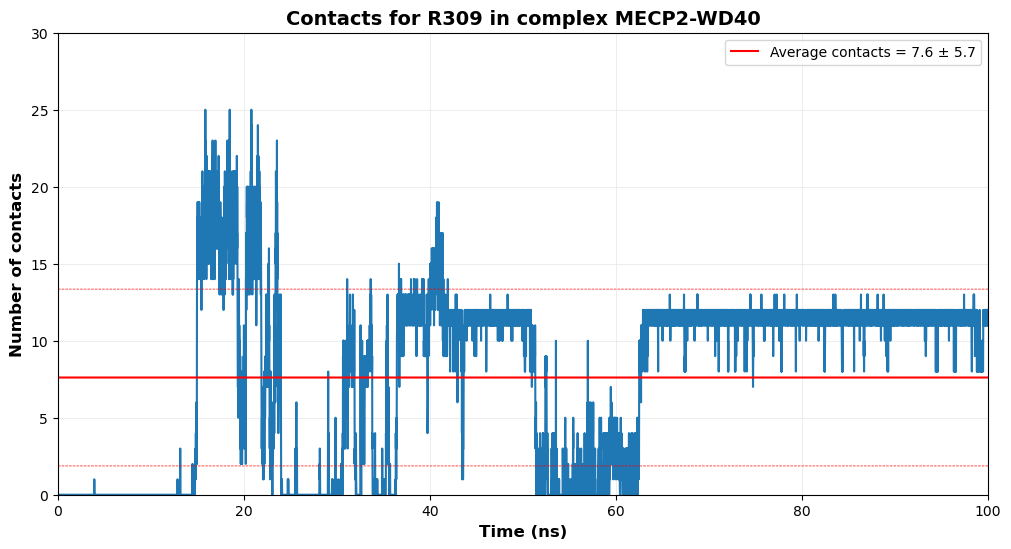

In [50]:
# Graph

plt.figure(figsize=(12,6))
plt.plot(ca_R309_co_df["Time (ns)"], ca_R309_co_df["# Contacts"])
plt.plot(ca_R309_co_df["Time (ns)"], np.full_like(ca_R309_co_df["Time (ns)"], moyenne_R309, dtype=float), linestyle="-", label=f"Average contacts = {moyenne_R309:.1f} ± {std_R309:.1f}", c="red")
plt.plot(ca_R309_co_df["Time (ns)"], np.full_like(ca_R309_co_df["Time (ns)"], (moyenne_R309 - std_R309), dtype=float), linestyle="--", c="red", linewidth=0.5)
plt.plot(ca_R309_co_df["Time (ns)"], np.full_like(ca_R309_co_df["Time (ns)"], (moyenne_R309 + std_R309), dtype=float), linestyle="--", c="red", linewidth=0.5)

plt.title(f"Contacts for R309 in complex {peptide}-{protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Number of contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0, 100)
plt.ylim(0, 30)
plt.legend()
plt.savefig(f"{base_path}R309_contacts_number_plot_{peptide}vs{protein}.png", dpi=300)
plt.show()

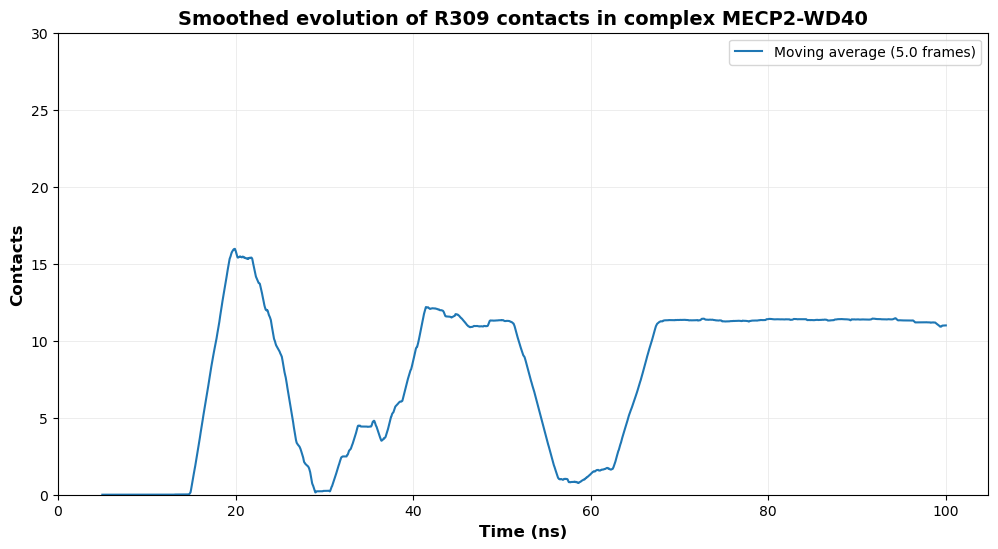

In [51]:
# Graph en "moyenne glissante" pour réduire le bruit de fond

ca_R309_co_df["Contacts_smooth"] = ca_R309_co_df["# Contacts"].rolling(window=windows).mean()

plt.figure(figsize=(12,6))
plt.plot(ca_R309_co_df["Time (ns)"], ca_R309_co_df["Contacts_smooth"], label=f"Moving average ({windows/100} frames)")
plt.title(f"Smoothed evolution of R309 contacts in complex {peptide}-{protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0,)
plt.ylim(0, 30)
plt.legend()
plt.savefig(f"{base_path}R309_contacts_smoothed_plot_{peptide}vs{protein}.png", dpi=300)
plt.show()

In [52]:
# Pour K304

In [53]:
ca_K304_co = contacts_within_cutoff(u_gro, K304, acidic, radius=4.5)

In [54]:
ca_K304_co_df = pd.DataFrame(ca_K304_co, columns=["Frame", "Time (ns)", "# Contacts"])
print(ca_K304_co_df.head(),"\n", ca_K304_co_df.tail())

   Frame  Time (ns)  # Contacts
0    0.0       0.00        14.0
1    1.0       0.01        13.0
2    2.0       0.02        15.0
3    3.0       0.03        13.0
4    4.0       0.04        14.0 
          Frame  Time (ns)  # Contacts
9996    9996.0      99.96        12.0
9997    9997.0      99.97        11.0
9998    9998.0      99.98         7.0
9999    9999.0      99.99         8.0
10000  10000.0     100.00         6.0


In [55]:
compte_K304 = ca_K304_co_df["# Contacts"].value_counts().sort_index()
#print(compte_K304)

moyenne_K304 = ca_K304_co_df["# Contacts"].mean()
print(moyenne_K304)

median_K304 = ca_K304_co_df["# Contacts"].median()
print(median_K304)

std_K304 = ca_K304_co_df["# Contacts"].std()
print(std_K304)

11.487551244875512
12.0
2.6534260896054183


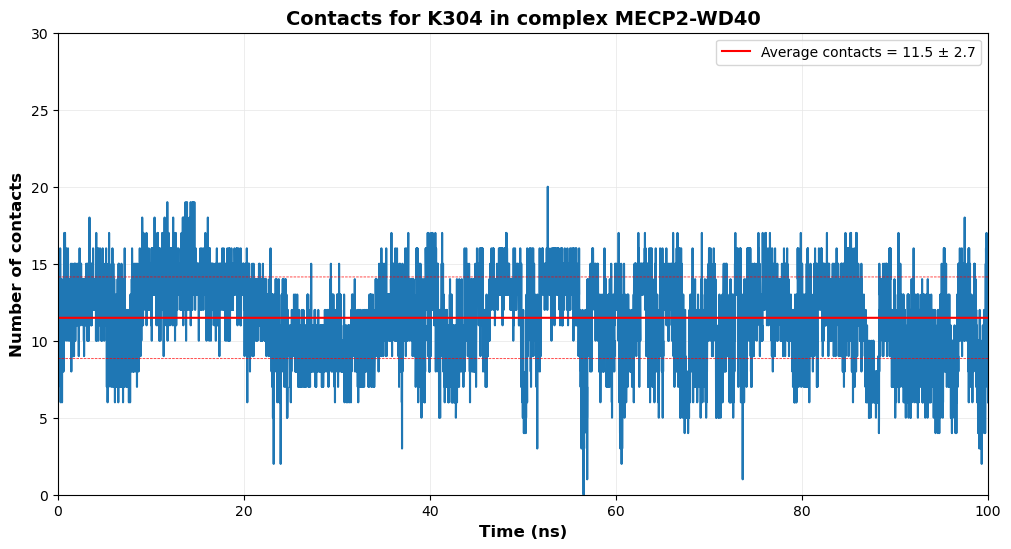

In [56]:
# Graph

plt.figure(figsize=(12,6))
plt.plot(ca_K304_co_df["Time (ns)"], ca_K304_co_df["# Contacts"])
plt.plot(ca_K304_co_df["Time (ns)"], np.full_like(ca_K304_co_df["Time (ns)"], moyenne_K304, dtype=float), linestyle="-", label=f"Average contacts = {moyenne_K304:.1f} ± {std_K304:.1f}", c="red")
plt.plot(ca_K304_co_df["Time (ns)"], np.full_like(ca_K304_co_df["Time (ns)"], (moyenne_K304 - std_K304), dtype=float), linestyle="--", c="red", linewidth=0.5)
plt.plot(ca_K304_co_df["Time (ns)"], np.full_like(ca_K304_co_df["Time (ns)"], (moyenne_K304 + std_K304), dtype=float), linestyle="--", c="red", linewidth=0.5)

plt.title(f"Contacts for K304 in complex {peptide}-{protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Number of contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0, 100)
plt.ylim(0, 30)
plt.legend()
plt.savefig(f"{base_path}K304_contacts_number_plot_{peptide}vs{protein}.png", dpi=300)
plt.show()

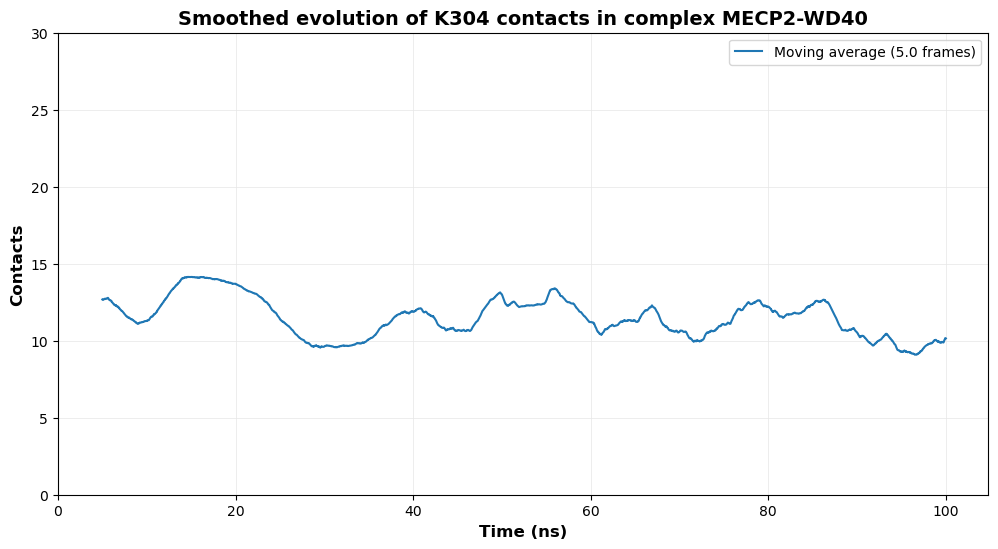

In [57]:
# Graph en "moyenne glissante" pour réduire le bruit de fond

ca_K304_co_df["Contacts_smooth"] = ca_K304_co_df["# Contacts"].rolling(window=windows).mean()

plt.figure(figsize=(12,6))
plt.plot(ca_K304_co_df["Time (ns)"], ca_K304_co_df["Contacts_smooth"], label=f"Moving average ({windows/100} frames)")
plt.title(f"Smoothed evolution of K304 contacts in complex {peptide}-{protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0,)
plt.ylim(0, 30)
plt.legend()
plt.savefig(f"{base_path}K304_contacts_smoothed_plot_{peptide}vs{protein}.png", dpi=300)
plt.show()

In [58]:
# Pour K305
from MDAnalysis.analysis import contacts

In [59]:
ca_K305_co = contacts_within_cutoff(u_gro, K305, acidic, radius=4.5)

In [60]:
ca_K305_co_df = pd.DataFrame(ca_K305_co, columns=["Frame", "Time (ns)", "# Contacts"])
print(ca_K305_co_df.head(),"\n", ca_K305_co_df.tail())

   Frame  Time (ns)  # Contacts
0    0.0       0.00        15.0
1    1.0       0.01        15.0
2    2.0       0.02        13.0
3    3.0       0.03        11.0
4    4.0       0.04        12.0 
          Frame  Time (ns)  # Contacts
9996    9996.0      99.96         1.0
9997    9997.0      99.97         1.0
9998    9998.0      99.98         2.0
9999    9999.0      99.99         2.0
10000  10000.0     100.00         1.0


In [61]:
compte_K305 = ca_K305_co_df["# Contacts"].value_counts().sort_index()
#print(compte_K305)

moyenne_K305 = ca_K305_co_df["# Contacts"].mean()
print(moyenne_K305)

median_K305 = ca_K305_co_df["# Contacts"].median()
print(median_K305)

std_K305 = ca_K305_co_df["# Contacts"].std()
print(std_K305)

7.666933306669333
7.0
6.995495370912024


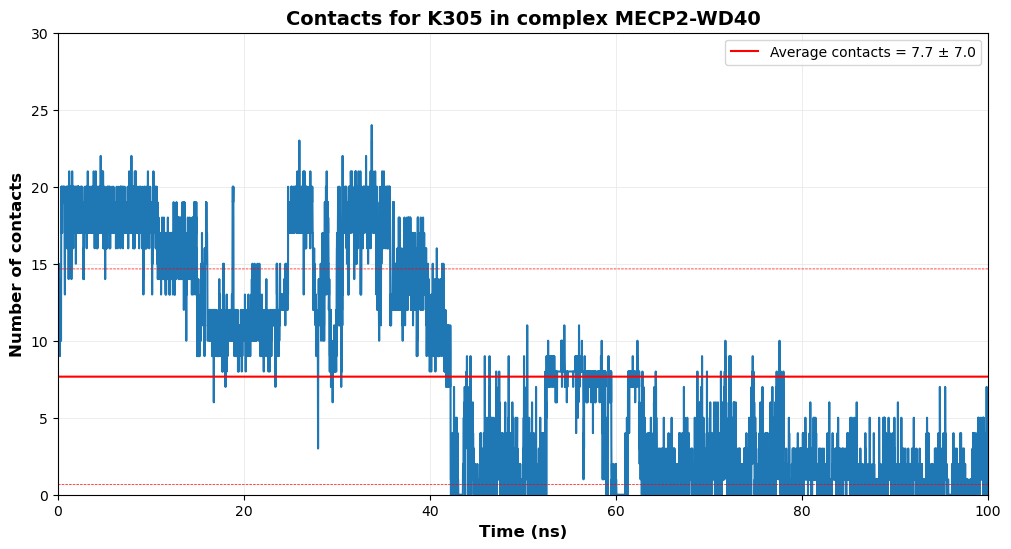

In [62]:
# Graph

plt.figure(figsize=(12,6))
#plt.scatter(ca_K305_co_df["Frame"], ca_K305_co_df["# Contacts"], s=10)
plt.plot(ca_K305_co_df["Time (ns)"], ca_K305_co_df["# Contacts"])
plt.plot(ca_K305_co_df["Time (ns)"], np.full_like(ca_K305_co_df["Time (ns)"], moyenne_K305, dtype=float), linestyle="-", label=f"Average contacts = {moyenne_K305:.1f} ± {std_K305:.1f}", c="red")
plt.plot(ca_K305_co_df["Time (ns)"], np.full_like(ca_K305_co_df["Time (ns)"], (moyenne_K305 - std_K305), dtype=float), linestyle="--", c="red", linewidth=0.5)
plt.plot(ca_K305_co_df["Time (ns)"], np.full_like(ca_K305_co_df["Time (ns)"], (moyenne_K305 + std_K305), dtype=float), linestyle="--", c="red", linewidth=0.5)

plt.title(f"Contacts for K305 in complex {peptide}-{protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Number of contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0, 100)
plt.ylim(0, 30)
plt.legend()
plt.savefig(f"{base_path}K305_contacts_number_plot_{peptide}vs{protein}.png", dpi=300)
plt.show()

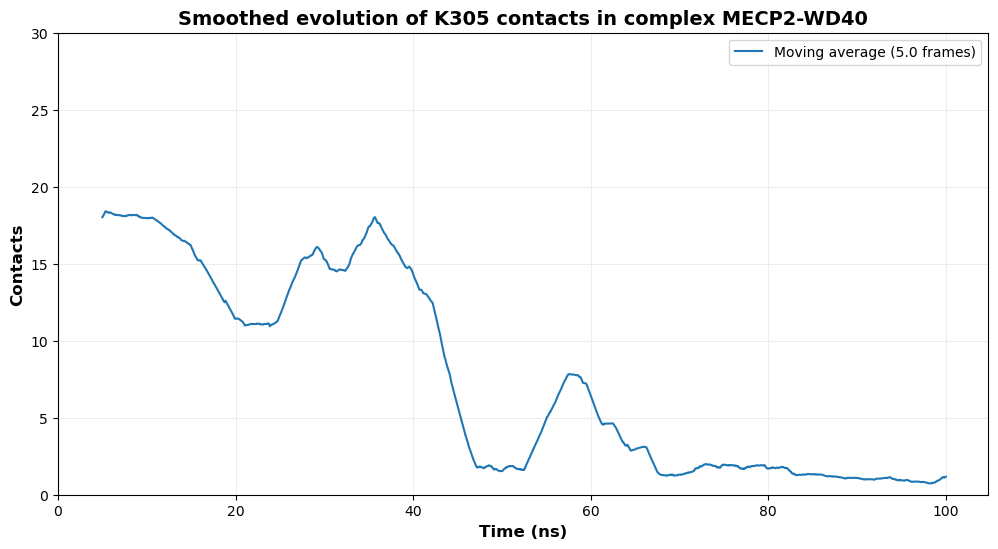

In [63]:
# Graph en "moyenne glissante" pour réduire le bruit de fond

ca_K305_co_df["Contacts_smooth"] = ca_K305_co_df["# Contacts"].rolling(window=windows).mean()

plt.figure(figsize=(12,6))
plt.plot(ca_K305_co_df["Time (ns)"], ca_K305_co_df["Contacts_smooth"], label=f"Moving average ({windows/100} frames)")
plt.title(f"Smoothed evolution of K305 contacts in complex {peptide}-{protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0,)
plt.ylim(0, 30)
plt.legend()
plt.savefig(f"{base_path}K305_contacts_smoothed_plot_{peptide}vs{protein}.png", dpi=300)
plt.show()

In [64]:
# Pour K307

In [65]:
ca_K307_co = contacts_within_cutoff(u_gro, K307, acidic, radius=4.5)

In [66]:
ca_K307_co_df = pd.DataFrame(ca_K307_co, columns=["Frame", "Time (ns)", "# Contacts"])
print(ca_K307_co_df.head(),"\n", ca_K307_co_df.tail())

   Frame  Time (ns)  # Contacts
0    0.0       0.00         5.0
1    1.0       0.01         6.0
2    2.0       0.02         1.0
3    3.0       0.03         1.0
4    4.0       0.04         1.0 
          Frame  Time (ns)  # Contacts
9996    9996.0      99.96        16.0
9997    9997.0      99.97        16.0
9998    9998.0      99.98        15.0
9999    9999.0      99.99        15.0
10000  10000.0     100.00        13.0


In [67]:
compte_K307 = ca_K307_co_df["# Contacts"].value_counts().sort_index()
#print(compte_K307)

moyenne_K307 = ca_K307_co_df["# Contacts"].mean()
print(moyenne_K307)

median_K307 = ca_K307_co_df["# Contacts"].median()
print(median_K307)

std_K307 = ca_K307_co_df["# Contacts"].std()
print(std_K307)

8.78932106789321
10.0
5.200895110363706


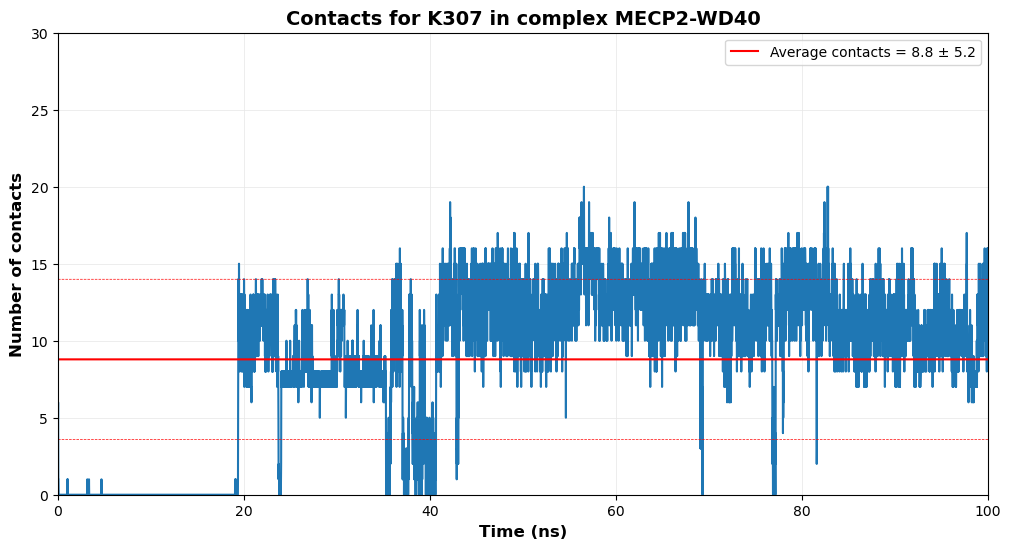

In [68]:
# Graph

plt.figure(figsize=(12, 6))
#plt.scatter(ca_K307_co_df["Time (ns)"], ca_K307_co_df["# Contacts"], s=10)
plt.plot(ca_K307_co_df["Time (ns)"], ca_K307_co_df["# Contacts"])
plt.plot(ca_K307_co_df["Time (ns)"], np.full_like(ca_K307_co_df["Time (ns)"], moyenne_K307, dtype=float), linestyle="-", label=f"Average contacts = {moyenne_K307:.1f} ± {std_K307:.1f}", c="red")
plt.plot(ca_K307_co_df["Time (ns)"], np.full_like(ca_K307_co_df["Time (ns)"], (moyenne_K307 - std_K307), dtype=float), linestyle="--", c="red", linewidth=0.5)
plt.plot(ca_K307_co_df["Time (ns)"], np.full_like(ca_K307_co_df["Time (ns)"], (moyenne_K307 + std_K307), dtype=float), linestyle="--", c="red", linewidth=0.5)

plt.title(f"Contacts for K307 in complex {peptide}-{protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Number of contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0, 100)
plt.ylim(0, 30)
plt.legend()
plt.savefig(f"{base_path}K307_contacts_number_plot_{peptide}vs{protein}.png", dpi=300)
plt.show()

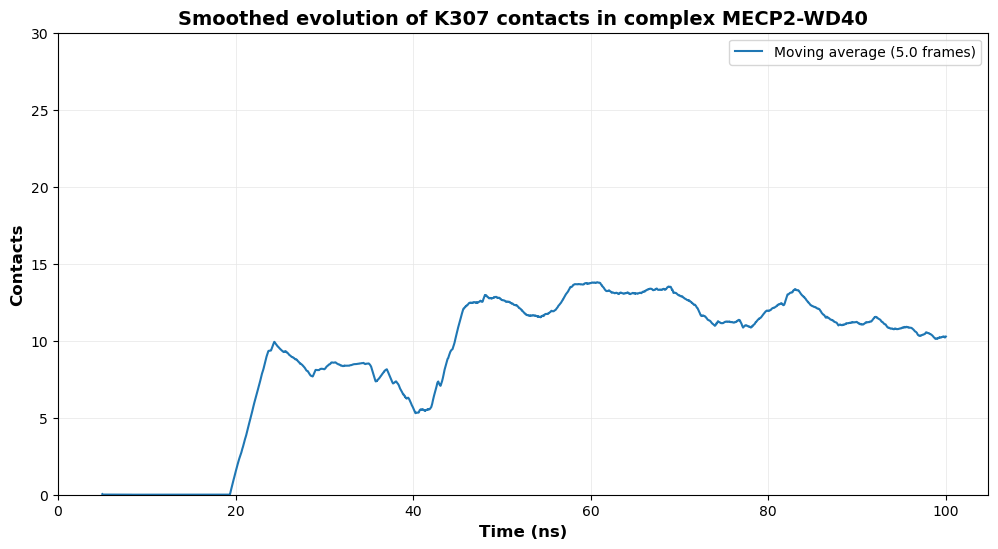

In [69]:
# Graph en "moyenne glissante" pour réduire le bruit de fond

ca_K307_co_df["Contacts_smooth"] = ca_K307_co_df["# Contacts"].rolling(window=windows).mean()

plt.figure(figsize=(12, 6))
plt.plot(ca_K307_co_df["Time (ns)"], ca_K307_co_df["Contacts_smooth"], label=f"Moving average ({windows/100} frames)")
plt.title(f"Smoothed evolution of K307 contacts in complex {peptide}-{protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0,)
plt.ylim(0, 30)
plt.legend()
plt.savefig(f"{base_path}K307_contacts_smoothed_plot_{peptide}vs{protein}.png", dpi=300)
plt.show()

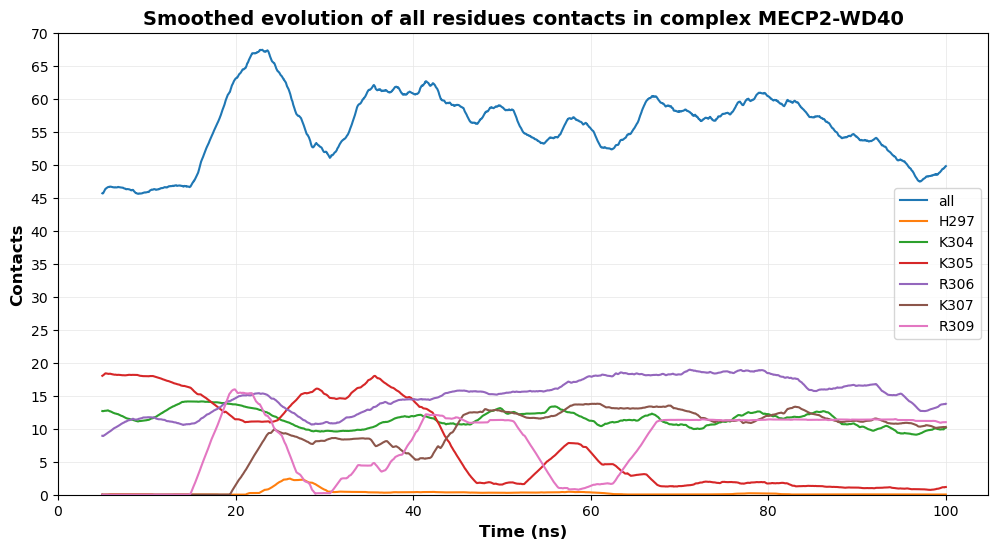

In [70]:
# Graph avec tous les résidus impliqués dans des contacts electrostatiques

plt.figure(figsize=(12,6))
plt.plot(ca_df["Time (ns)"], ca_df["Contacts_smooth"], label="all")
plt.plot(ca_df["Time (ns)"], ca_H297_co_df["Contacts_smooth"], label="H297")
plt.plot(ca_df["Time (ns)"], ca_K304_co_df["Contacts_smooth"], label="K304")
plt.plot(ca_df["Time (ns)"], ca_K305_co_df["Contacts_smooth"], label="K305")
plt.plot(ca_df["Time (ns)"], ca_R306_co_df["Contacts_smooth"], label="R306")
plt.plot(ca_df["Time (ns)"], ca_K307_co_df["Contacts_smooth"], label="K307")
plt.plot(ca_df["Time (ns)"], ca_R309_co_df["Contacts_smooth"], label="R309")

plt.title(f"Smoothed evolution of all residues contacts in complex {peptide}-{protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Contacts", fontsize=12, fontweight="bold")
plt.xlim(0,)
plt.ylim(0, 70)

plt.gca().yaxis.set_major_locator(MultipleLocator(5))
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.legend()
plt.savefig(f"{base_path}all_residues_contacts_smoothed_plot_{peptide}vs{protein}.png", dpi=300)
plt.show()

In [71]:
########## Calcul et plot de l'énergie de liaisons Peptide-Proteine au cours du temps ##########

In [72]:
"""
Calculate MM binding energy (Electrostatic + VdW) in kJ/mol
Uses simplified Coulomb and Lennard-Jones potentials
"""

print("Calculating MM Binding Energy...")

energies = []
time_ns = []

# Constants
epsilon_0 = 8.854187817e-12  # Vacuum permittivity (F/m)
epsilon_r = 1.0  # Relative permittivity (vacuum approximation)
e = 1.602176634e-19  # Elementary charge (C)
Na = 6.02214076e23  # Avogadro's number

# Coulomb constant in kJ/(mol·nm)
# k_e = (1 / (4π * ε₀ * ε_r)) * e² * Na / 1000
k_e = 138.935458  # kJ·nm/(mol·e²) - standard value for MD simulations

# Lennard-Jones parameters (typical protein-ligand values)
epsilon_lj = 0.5  # kJ/mol - depth of potential well
sigma = 0.35  # nm - distance at which potential is zero

for ts in u_gro.trajectory:
    # Get protein-ligand distance matrix in Angstroms
    distances_angstrom = mda.lib.distances.distance_array(MRD.positions, WD40.positions)

    # Convert to nm for proper energy calculation
    distances_nm = distances_angstrom / 10.0

    # Avoid division by zero
    distances_nm = np.maximum(distances_nm, 0.01)  # Minimum distance 0.01 nm

    # Electrostatic energy (Coulomb's law)
    # E_elec = k_e * q1 * q2 / r
    # Assuming partial charges of ±0.5e for simplified calculation
    q_protein = 0.5  # Partial charge (elementary charge units)
    q_ligand = 0.5
    elec_energy = k_e * q_protein * q_ligand / distances_nm
    total_elec = np.sum(elec_energy)

    # Van der Waals energy (Lennard-Jones 6-12 potential)
    # E_vdw = 4ε[(σ/r)^12 - (σ/r)^6]
    sigma_r = sigma / distances_nm
    vdw_energy = 4 * epsilon_lj * (sigma_r**12 - sigma_r**6)
    total_vdw = np.sum(vdw_energy)

    # Total interaction energy
    total_energy = total_elec + total_vdw

    energies.append(total_energy)
    time_ns.append(ts.time / 1000.0)

print("Calcul MM Binding Energy done!")

Calculating MM Binding Energy...
Calcul MM Binding Energy done!


Binding energy plot saved to C:/Users/e216138h/Desktop/Stage/Dossier_Florent/M2/Modelisation/Partenaire/TBL1R/DM/new_MD/mMECP2_100ns/WT/energy.png
Mean Energy: 21768697.43 ± 258073.15 kJ/mol


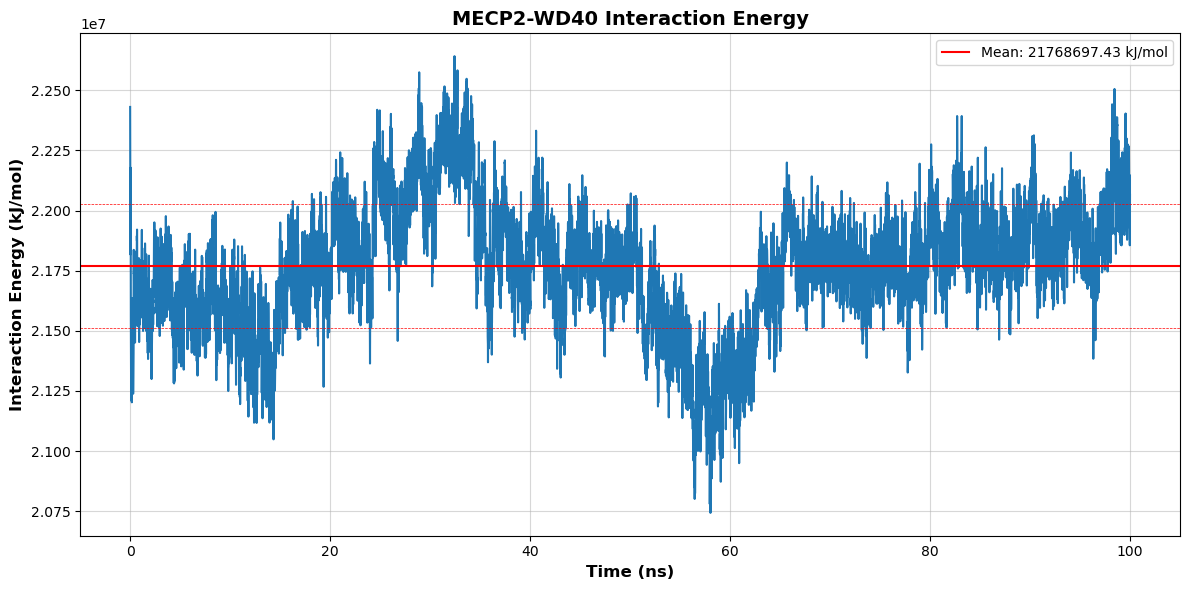

In [73]:
"""
Plot binding energy over time in kJ/mol
"""

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(time_ns, energies)
ax.set_xlabel("Time (ns)", fontsize=12, fontweight="bold")
ax.set_ylabel("Interaction Energy (kJ/mol)", fontsize=12, fontweight="bold")
ax.set_title(f"{peptide}-{protein} Interaction Energy", fontsize=14, fontweight="bold")
ax.grid(alpha=0.5)

mean_energy = np.mean(energies)
std_energy = np.std(energies)
ax.axhline(mean_energy, c="red", linestyle="-", label=f"Mean: {mean_energy:.2f} kJ/mol")
ax.axhline((mean_energy - std_energy), c="red", linestyle="--", linewidth=0.5)
ax.axhline((mean_energy + std_energy), c="red", linestyle="--", linewidth=0.5)
ax.legend()

plt.tight_layout()
plt.savefig(f"{base_path}energy.png", dpi=300)
print(f"Binding energy plot saved to {base_path}energy.png")
print(f"Mean Energy: {mean_energy:.2f} ± {std_energy:.2f} kJ/mol")
plt.show()

In [74]:
"""Calculate RMSD over trajectory"""

self = u_gro
selection="backbone"
reference_frame=0

print("Calculating RMSD...")

if selection == "backbone":
    sel = self.select_atoms("backbone")
elif selection == "name CA":
    sel = self.select_atoms("name CA")
else:
    sel = self.select_atoms(selection)

R = rms.RMSD(sel, sel, select=selection, ref_frame=reference_frame)
R.run()

# Convert time to ns
time_ns = R.results.rmsd[:, 1] / 1000.0
rmsd_values = R.results.rmsd[:, 2]

print("Calcul RMSD done!")

Calculating RMSD...
Calcul RMSD done!


RMSD plot saved to C:/Users/e216138h/Desktop/Stage/Dossier_Florent/M2/Modelisation/Partenaire/TBL1R/DM/new_MD/mMECP2_100ns/WT/rmsd.png


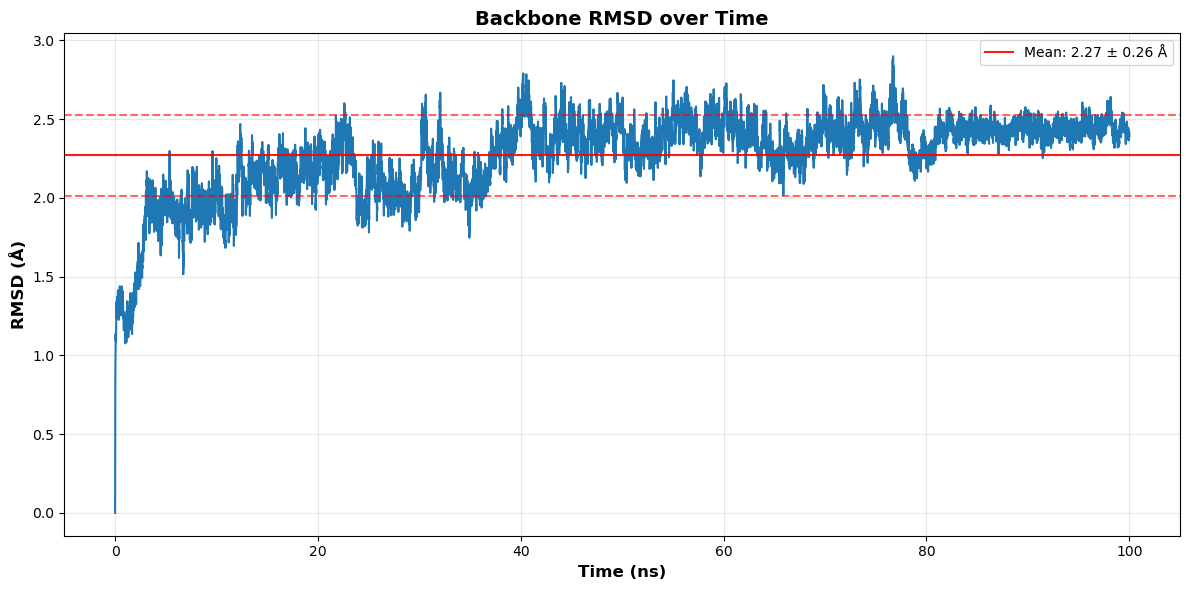

In [75]:
"""Plot RMSD vs Time"""

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(time_ns, rmsd_values)
ax.set_title("Backbone RMSD over Time", fontsize=14, fontweight="bold")
ax.set_xlabel("Time (ns)", fontsize=12, fontweight="bold")
ax.set_ylabel("RMSD (Å)", fontsize=12, fontweight="bold")
ax.grid(alpha=0.3)

# Add statistics - only mean line
mean_rmsd = np.mean(rmsd_values)
std_rmsd = np.std(rmsd_values)
ax.axhline(mean_rmsd, color="red", linestyle="-", alpha=0.9, label=f"Mean: {mean_rmsd:.2f} ± {std_rmsd:.2f} Å")
ax.axhline(mean_rmsd - std_rmsd, color="red", linestyle="--", alpha=0.6)
ax.axhline(mean_rmsd + std_rmsd, color="red", linestyle="--", alpha=0.6)
ax.legend()

plt.tight_layout()
plt.savefig(f"{base_path}rmsd.png", dpi=300)
print(f"RMSD plot saved to {base_path}rmsd.png")
plt.show()